In [1]:
import wandb
import pandas as pd

# Login to wandb (if not already logged in)
wandb.login()

# Initialize API
api = wandb.Api()

PROJECT_NAME = "solid_deception_iterative"

print(f"Loading runs from: farai/{PROJECT_NAME}")
runs = api.runs(f"farai/{PROJECT_NAME}")

# Check if we got any runs
runs_list = list(runs)
print(f"Found {len(runs_list)} runs in this project")

if len(runs_list) == 0:
    print("No runs found in this project. Try a different project name.")
    # List first few projects again for reference
    print("Available projects:")
    for i, project in enumerate(api.projects(entity="farai")):
        if i < 10:  # Show first 10
            print(f"- {project.name}")
        else:
            break

# Extract data into a list of dictionaries
data = []
for run in runs_list:  # Use the list we created above
    # Get run metadata and config
    run_data = {
        'run_id': run.id,
        'name': run.name,
        'state': run.state,
        'created_at': run.created_at,
        'duration': getattr(run, 'duration', None),  # Safer attribute access
        'tags': run.tags,
        'notes': run.notes,
    }

    # Add config parameters
    for key, value in run.config.items():
        run_data[f'config_{key}'] = value

    # Add summary metrics (final values)
    for key, value in run.summary.items():
        run_data[f'summary_{key}'] = value

    data.append(run_data)

# Convert to DataFrame
df = pd.DataFrame(data)

# Display basic info
print(f"Loaded {len(df)} runs")
print(f"Columns: {df.columns.tolist()}")
df.head()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rrmaura (farai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loading runs from: farai/solid_deception_iterative
Found 664 runs in this project
Loaded 664 runs
Columns: ['run_id', 'name', 'state', 'created_at', 'duration', 'tags', 'notes', 'config_data_limit', 'config_experiment_set_name', 'config_experiment_type', 'summary__runtime', 'summary__step', 'summary__timestamp', 'summary__wandb.runtime', 'summary_fit_C', 'summary_fit_auc', 'summary_fit_fpr', 'summary_fit_roc_table', 'summary_fit_tpr', 'summary_full_dataset_avg_deceptive_lr_lie', 'summary_full_dataset_avg_truthful_lr_lie', 'summary_full_dataset_fpr', 'summary_full_dataset_tpr', 'summary_specified_tpr', 'summary_threshold', 'config___cached__setup_devices', 'config__attn_implementation_autoset', 'config__n_gpu', 'config__name_or_path', 'config_accelerator_config', 'config_adafactor', 'config_adam_beta1', 'config_adam_beta2', 'config_adam_epsilon', 'config_add_cross_attention', 'config_architectures', 'config_attention_bias', 'config_attention_dropout', 'config_attn_implementation', 'conf

,run_id,name,state,created_at,duration,tags,notes,config_data_limit,config_experiment_set_name,config_experiment_type,...,summary_generated_deceptive_undetected_0_999_threshold,summary_generated_deceptive_undetected_0_99_threshold,summary_generated_sft_deceptive_undetected_0_95_threshold,summary_generated_sft_deceptive_undetected_0_985_threshold,summary_generated_sft_deceptive_undetected_0_98_threshold,summary_generated_sft_deceptive_undetected_0_999_threshold,summary_generated_sft_deceptive_undetected_0_99_threshold,config_lie_tpr,config_num_iterations,config_subsample_dataset
0,diybkpey,detector_iter1_20250718_114350,finished,2025-07-18T11:45:34Z,None,[],None,NaN,20250718_114350,Detector,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,w0oplvv8,sft_iter1_20250718_114350,failed,2025-07-18T11:47:07Z,None,[],None,NaN,20250718_114350,SFT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,qb9y2v7f,detector_iter1_20250718_115136,finished,2025-07-18T11:53:04Z,None,[],None,NaN,20250718_115136,Detector,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,lpcyolep,sft_iter1_20250718_115136,finished,2025-07-18T11:54:45Z,None,[],None,NaN,20250718_115136,SFT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,y6ul874j,dpo_iter1_20250718_115136,failed,2025-07-18T11:56:58Z,None,[],None,NaN,20250718_115136,DPO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Matrices

In [3]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

def filter_experiments_by_tpr(df, tpr_value, subsample=False, num_iterations=2, experiment_type="MergedProbeEvaluation"):
    """
    Filter experiments by TPR and other parameters
    """
    # Find column names
    config_cols = [col for col in df.columns if col.startswith('config_')]

    col_mapping = {}
    for col in config_cols:
        if 'lie_tpr' in col.lower():
            col_mapping['tpr'] = col
        elif 'subsample_dataset' in col.lower():
            col_mapping['subsample'] = col
        elif 'num_iterations' in col.lower():
            col_mapping['iterations'] = col
        elif col == 'config_experiment_type':
            col_mapping['exp_type'] = col

    # Apply filters
    filtered_df = df.copy()

    if 'tpr' in col_mapping:
        filtered_df = filtered_df[filtered_df[col_mapping['tpr']] == tpr_value]

    if 'subsample' in col_mapping:
        subsample_values = [True, "True", "true"] if subsample else [False, "False", "false"]
        filtered_df = filtered_df[filtered_df[col_mapping['subsample']].isin(subsample_values)]

    if 'iterations' in col_mapping:
        filtered_df = filtered_df[filtered_df[col_mapping['iterations']] == num_iterations]

    if 'exp_type' in col_mapping:
        filtered_df = filtered_df[filtered_df[col_mapping['exp_type']] == experiment_type]

    print(f"TPR {tpr_value}: {len(filtered_df)} experiments found")
    return filtered_df

def extract_confusion_matrix(api, project_name, run_id):
    """
    Extract confusion matrix from a single run
    """
    try:
        run = api.run(f"farai/{project_name}/{run_id}")

        if "confusion_matrix_table" not in run.summary:
            return None

        # Find confusion matrix file
        files = run.files()
        table_file = None
        for file in files:
            if "confusion_matrix_table" in file.name and file.name.endswith('.json'):
                table_file = file
                break

        if not table_file:
            return None

        # Download and parse
        table_file.download(replace=True)
        with open(table_file.name, 'r') as f:
            table_data = json.load(f)

        # Convert to numpy array
        cm = np.array(table_data['data'], dtype=float)
        return cm

    except Exception as e:
        print(f"Error extracting matrix from run {run_id}: {e}")
        return None

def collect_matrices_by_tpr(df, api, project_name, tpr_values=[0.6, 0.8, 0.99]):
    """
    Collect confusion matrices organized by TPR value
    """
    matrices_dict = {}

    for tpr in tpr_values:
        print(f"\nProcessing TPR {tpr}...")

        # Filter experiments
        experiments = filter_experiments_by_tpr(df, tpr)

        # Extract matrices
        matrices = []
        for run_id in experiments['run_id']:
            cm = extract_confusion_matrix(api, project_name, run_id)
            if cm is not None:
                matrices.append(cm)
                print(f"  Run {run_id}: {cm.shape} matrix")

        matrices_dict[tpr] = matrices
        print(f"  Total matrices for TPR {tpr}: {len(matrices)}")

    return matrices_dict

def quick_visualize_matrices(matrices_list, tpr_value):
    """
    Quick visualization of matrices for a given TPR
    """
    if not matrices_list:
        print(f"No matrices found for TPR {tpr_value}")
        return

    n_matrices = len(matrices_list)
    cols = min(4, n_matrices)
    rows = (n_matrices + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    for i, cm in enumerate(matrices_list):
        if i < len(axes):
            sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues',
                       ax=axes[i], cbar=False)
            axes[i].set_title(f'Matrix {i+1}')
            axes[i].set_xlabel('Predicted')
            axes[i].set_ylabel('True')

    # Hide unused subplots
    for i in range(n_matrices, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle(f'Confusion Matrices for TPR {tpr_value}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Example usage and verification:
def get_matrices_dictionary(df, api, project_name):
    """
    Run the complete analysis and verify results
    """
    print("=== COLLECTING MATRICES BY TPR ===")
    matrices_dict = collect_matrices_by_tpr(df, api, project_name)

    print(f"\n=== SUMMARY ===")
    for tpr, matrices in matrices_dict.items():
        print(f"TPR {tpr}: {len(matrices)} matrices")

    return matrices_dict

# To execute (replace with your actual variables):
# matrices_dict = run_analysis_example(df, api, PROJECT_NAME)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def to_percentages(matrix):
    """Convert any matrix to percentages (sum = 100%)"""
    return (matrix / np.sum(matrix)) * 100

def generate_theoretical_matrix(n, tpr, dependent=False):
    """
    Generate theoretical 2x2 matrix for binary classifiers

    Args:
        n: number of units
        tpr: true positive rate (same for both classifiers)
        dependent: if True, classifiers are perfectly dependent

    Returns:
        2x2 matrix in format:
        [[both_detect, c2_only], [c1_only, both_miss]]
    """
    if dependent:
        # Perfect dependence: classifiers make identical decisions
        both_detect = n * tpr
        both_miss = n * (1 - tpr)
        disagreement = 0
        matrix = np.array([[both_detect, disagreement],
                          [disagreement, both_miss]])
    else:
        # Independence: decisions are independent
        both_detect = n * tpr * tpr
        c1_only = n * tpr * (1 - tpr)
        c2_only = n * (1 - tpr) * tpr
        both_miss = n * (1 - tpr) * (1 - tpr)
        matrix = np.array([[both_detect, c2_only],
                          [c1_only, both_miss]])

    return matrix

def plot_matrix(matrix, title, ax, show_se=False, se_matrix=None):
    """
    Plot a single matrix as heatmap with percentage annotations

    Args:
        matrix: 2x2 matrix (will be converted to percentages)
        title: plot title
        ax: matplotlib axis
        show_se: whether to show standard errors
        se_matrix: standard error matrix (if show_se=True)
    """
    pct_matrix = to_percentages(matrix)

    # Create annotations
    if show_se and se_matrix is not None:
        annot_matrix = np.empty((2, 2), dtype=object)
        for i in range(2):
            for j in range(2):
                mean = pct_matrix[i, j]
                se = se_matrix[i, j]
                annot_matrix[i, j] = f'{mean:.1f}%\n± {se:.1f}'
        fmt = ''
        annot_kws = {'size': 16, 'va': 'center'}
    else:
        annot_matrix = np.empty((2, 2), dtype=object)
        for i in range(2):
            for j in range(2):
                annot_matrix[i, j] = f'{pct_matrix[i, j]:.0f}%'
        fmt = ''
        annot_kws = {'size': 16}

    # Default color scale, no color bar, larger font sizes
    sns.heatmap(pct_matrix, annot=annot_matrix, fmt=fmt, cmap='Blues',
                ax=ax, cbar=False,
                annot_kws=annot_kws)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Classifier 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('Classifier 2', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Detect', 'Miss'], fontsize=14, fontweight='bold')
    ax.set_yticklabels(['Detect', 'Miss'], fontsize=14, fontweight='bold')

def process_simulation_data(matrices_list):
    """
    Process simulation data: convert to percentages and calculate mean ± SE

    Args:
        matrices_list: list of 4 2x2 matrices

    Returns:
        mean_matrix, se_matrix (both as percentages)
    """
    matrices = np.array(matrices_list)

    # Convert each matrix to percentages
    pct_matrices = np.array([to_percentages(matrix) for matrix in matrices])

    # Calculate mean and standard error
    mean_matrix = np.mean(pct_matrices, axis=0)
    se_matrix = np.std(pct_matrices, axis=0, ddof=1) / np.sqrt(len(matrices))

    return mean_matrix, se_matrix

def plot_simulation_results(simulation_data):
    """
    Plot empirical simulation results as single heatmap with mean ± SE

    Args:
        simulation_data: list of 2x2 matrices from simulations
    """
    mean_matrix, se_matrix = process_simulation_data(simulation_data)

    fig, ax = plt.subplots(figsize=(6, 5))
    plot_matrix(mean_matrix, 'Simulation Results (Mean ± SE)',
               ax, show_se=True, se_matrix=se_matrix)

    plt.tight_layout()
    plt.show()

    return mean_matrix, se_matrix

def plot_theoretical_comparison(tpr_values=[0.6, 0.8, 0.99], n=1000):
    """
    Plot theoretical comparison of independent vs dependent classifiers

    Args:
        tpr_values: list of TPR values to compare
        n: number of units for theoretical calculations
    """
    n_scenarios = len(tpr_values)

    # Create 2 rows: top=independent, bottom=dependent
    fig, axes = plt.subplots(2, n_scenarios, figsize=(5*n_scenarios, 8))

    # Handle case where there's only one TPR value
    if n_scenarios == 1:
        axes = axes.reshape(2, 1)

    for i, tpr in enumerate(tpr_values):
        # Independent case (top row)
        matrix_indep = generate_theoretical_matrix(n, tpr, dependent=False)
        plot_matrix(matrix_indep, f'Independent\nTPR = {tpr}', axes[0, i])

        # Dependent case (bottom row)
        matrix_dep = generate_theoretical_matrix(n, tpr, dependent=True)
        plot_matrix(matrix_dep, f'Perfect Dependence\nTPR = {tpr}', axes[1, i])

    plt.tight_layout()
    plt.show()


In [5]:
df_filter_seeds = df[df['config_seed'].isin([11, 22, 33, 44])]

matrices_dict = get_matrices_dictionary(df_filter_seeds, api, PROJECT_NAME)


=== COLLECTING MATRICES BY TPR ===

Processing TPR 0.6...
TPR 0.6: 4 experiments found
  Run t4yf0fm0: (2, 2) matrix
  Run g1igar79: (2, 2) matrix
  Run 8xvbpn1x: (2, 2) matrix
  Run a33pazpp: (2, 2) matrix
  Total matrices for TPR 0.6: 4

Processing TPR 0.8...
TPR 0.8: 4 experiments found
  Run 4hgda9ni: (2, 2) matrix
  Run x5q8pu6s: (2, 2) matrix
  Run k9tvekyl: (2, 2) matrix
  Run zrkiqast: (2, 2) matrix
  Total matrices for TPR 0.8: 4

Processing TPR 0.99...
TPR 0.99: 4 experiments found
  Run lesnup8l: (2, 2) matrix
  Run owf9niqh: (2, 2) matrix
  Run jf7jpdni: (2, 2) matrix
  Run fko7y92z: (2, 2) matrix
  Total matrices for TPR 0.99: 4

=== SUMMARY ===
TPR 0.6: 4 matrices
TPR 0.8: 4 matrices
TPR 0.99: 4 matrices


# Comparison: on one go to 2 steps


In [6]:
import numpy as np
import pandas as pd

def filter_eval_experiments(df):
    """
    Filter dataframe for Eval experiments with specified criteria
    """
    filtered_df = df.copy()

    # Filter for Eval experiments
    if 'config_experiment_type' in df.columns:
        filtered_df = filtered_df[filtered_df['config_experiment_type'] == 'Eval']
        print(f"After Eval filter: {len(filtered_df)} experiments")

    # Filter for subsample_dataset = False
    if 'config_subsample_dataset' in df.columns:
        # Handle different representations of False
        false_values = [False, 'False', 'false', 0, '0']
        filtered_df = filtered_df[filtered_df['config_subsample_dataset'].isin(false_values)]
        print(f"After subsample=False filter: {len(filtered_df)} experiments")

    # Filter for num_iterations in [1.0, 2.0]
    if 'config_num_iterations' in df.columns:
        filtered_df = filtered_df[filtered_df['config_num_iterations'].isin([1.0, 2.0])]
        print(f"After iterations filter: {len(filtered_df)} experiments")

    print(f"Final filtered dataset: {len(filtered_df)} experiments")
    return filtered_df

def compare_iterations_by_tpr(df, tpr_value, column_name):
    """
    Compare mean values of a column between 1.0 and 2.0 iterations for a specific TPR

    Args:
        df: filtered dataframe (should already be filtered for Eval experiments)
        tpr_value: TPR value to filter on (e.g., 0.6, 0.8, 0.99)
        column_name: name of the column to analyze (e.g., 'accuracy', 'f1_score')

    Returns:
        dict with results for both iterations
    """

    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in dataframe")
        return None

    if 'config_lie_tpr' not in df.columns:
        print("Error: config_lie_tpr column not found")
        return None

    # Filter for specific TPR
    tpr_df = df[df['config_lie_tpr'] == tpr_value].copy()
    print(f"\nAnalyzing TPR {tpr_value} - Column: {column_name}")
    print(f"Total experiments for this TPR: {len(tpr_df)}")

    results = {}

    for iterations in [1.0, 2.0]:
        iter_df = tpr_df[tpr_df['config_num_iterations'] == iterations]

        if len(iter_df) == 0:
            print(f"  No data for {iterations} iterations")
            results[iterations] = {
                'mean': None,
                'se': None,
                'n': 0,
                'seeds': []
            }
            continue

        # Get values for this iteration
        values = iter_df[column_name].dropna()
        seeds = iter_df['config_seed'].tolist()

        if len(values) == 0:
            print(f"  No valid values for {iterations} iterations")
            results[iterations] = {
                'mean': None,
                'se': None,
                'n': 0,
                'seeds': seeds
            }
            continue

        # Calculate statistics
        mean_val = np.mean(values)
        se_val = np.std(values, ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0

        results[iterations] = {
            'mean': mean_val,
            'se': se_val,
            'n': len(values),
            'seeds': seeds
        }

        print(f"  {iterations} iterations: Mean = {mean_val:.4f} ± {se_val:.4f} (n={len(values)} seeds)")
        print(f"    Seeds: {sorted(seeds)}")

    return results

def comprehensive_comparison(df, column_name, tpr_values=[0.6, 0.8, 0.99]):
    """
    Run comparison across all TPR values for a given column
    """
    print(f"\n{'='*60}")
    print(f"COMPREHENSIVE COMPARISON FOR COLUMN: {column_name}")
    print(f"{'='*60}")

    all_results = {}

    for tpr in tpr_values:
        results = compare_iterations_by_tpr(df, tpr, column_name)
        all_results[tpr] = results

        # Print summary comparison
        if results and results[1.0]['mean'] is not None and results[2.0]['mean'] is not None:
            diff = results[2.0]['mean'] - results[1.0]['mean']
            print(f"  Difference (2.0 - 1.0): {diff:.4f}")
        print(f"  {'-'*40}")

    return all_results

def print_summary_table(all_results, column_name):
    """
    Print a nice summary table of all results
    """
    print(f"\n{'='*80}")
    print(f"SUMMARY TABLE: {column_name}")
    print(f"{'='*80}")
    print(f"{'TPR':<6} {'Iter':<6} {'Mean':<12} {'SE':<12} {'N':<6} {'95% CI':<20}")
    print(f"{'-'*80}")

    for tpr in sorted(all_results.keys()):
        for iterations in [1.0, 2.0]:
            result = all_results[tpr][iterations]
            if result['mean'] is not None:
                ci_lower = result['mean'] - 1.96 * result['se']
                ci_upper = result['mean'] + 1.96 * result['se']
                ci_str = f"({ci_lower:.3f}, {ci_upper:.3f})"

                print(f"{tpr:<6} {iterations:<6} {result['mean']:<12.4f} {result['se']:<12.4f} "
                      f"{result['n']:<6} {ci_str:<20}")
            else:
                print(f"{tpr:<6} {iterations:<6} {'N/A':<12} {'N/A':<12} {result['n']:<6} {'N/A':<20}")


In [7]:
import pandas as pd
import numpy as np
import re

def parse_eval_name(name):
    """
    Parse eval experiment name to extract hyperparameters

    Expected patterns:
    - eval_iter1_20250720_115517_TPR_0.6_SEED_22_SUBSAMPLE_True_ITER_2
    - eval_iter2_20250720_103620_TPR_0.99_SEED_123_SUBSAMPLE_False_ITER_2
    - eval_iter1_20250720_085026_TPR_0.6_SEED_123_SUBSAMPLE_False_ITER_1

    Returns:
        dict with extracted parameters
    """
    if pd.isna(name) or not isinstance(name, str):
        return {}

    params = {}

    # Extract TPR
    tpr_match = re.search(r'TPR_([0-9.]+)', name)
    if tpr_match:
        params['config_lie_tpr'] = float(tpr_match.group(1))

    # Extract SEED
    seed_match = re.search(r'SEED_([0-9]+)', name)
    if seed_match:
        params['config_seed'] = float(seed_match.group(1))

    # Extract SUBSAMPLE
    subsample_match = re.search(r'SUBSAMPLE_(True|False)', name)
    if subsample_match:
        params['config_subsample_dataset'] = subsample_match.group(1)

    # Extract ITER (number of iterations)
    iter_match = re.search(r'ITER_([0-9]+)', name)
    if iter_match:
        params['config_num_iterations'] = float(iter_match.group(1))

    # Extract iteration phase (iter1 or iter2)
    iter_phase_match = re.search(r'eval_(iter[12])_', name)
    if iter_phase_match:
        params['iteration_phase'] = iter_phase_match.group(1)

    return params

def fill_eval_config_columns(df):
    """
    Fill missing config columns for Eval experiments by parsing the name column
    """
    df_filled = df.copy()

    # Find Eval experiments
    eval_mask = df_filled['config_experiment_type'] == 'Eval'
    eval_indices = df_filled[eval_mask].index

    print(f"Found {len(eval_indices)} Eval experiments")

    filled_count = 0
    for idx in eval_indices:
        name = df_filled.loc[idx, 'name']

        # Parse the name to extract parameters
        parsed_params = parse_eval_name(name)

        if parsed_params:
            # Fill the missing values
            for param_name, param_value in parsed_params.items():
                if param_name not in df_filled.columns or pd.isna(df_filled.loc[idx, param_name]):
                    df_filled.loc[idx, param_name] = param_value
            filled_count += 1

    print(f"Successfully filled config columns for {filled_count} Eval experiments")

    return df_filled

def verify_eval_filling(df_original, df_filled):
    """
    Verify that the filling worked correctly
    """
    eval_mask = df_filled['config_experiment_type'] == 'Eval'
    eval_df = df_filled[eval_mask]

    print("\n=== VERIFICATION ===")
    print(f"Total Eval experiments: {len(eval_df)}")

    # Check each config column
    config_cols = ['config_lie_tpr', 'config_seed', 'config_subsample_dataset', 'config_num_iterations', 'iteration_phase']


    for col in config_cols:
        if col in eval_df.columns:
            non_nan_count = eval_df[col].notna().sum()
            print(f"{col}: {non_nan_count}/{len(eval_df)} filled")

            # Show unique values
            unique_vals = eval_df[col].dropna().unique()
            print(f"  Unique values: {sorted(unique_vals) if len(unique_vals) < 10 else f'{len(unique_vals)} unique values'}")

    # Show some examples
    print("\n=== EXAMPLES ===")
    sample_eval = eval_df[eval_df['config_lie_tpr'].notna()].head(3)
    for idx, row in sample_eval.iterrows():
        print(f"Name: {row['name']}")
        print(f"  TPR: {row['config_lie_tpr']}, Seed: {row['config_seed']}, "
            f"Subsample: {row['config_subsample_dataset']}, Iterations: {row['config_num_iterations']}, Phase: {row['iteration_phase']}")
        print()

def run_filling_process(df):
    """
    Complete process to fill and verify Eval config columns
    """
    print("=== FILLING EVAL CONFIG COLUMNS ===")

    # Show before state
    eval_mask = df['config_experiment_type'] == 'Eval'
    eval_before = df[eval_mask]
    print(f"Before filling - Eval experiments with valid TPR: {eval_before['config_lie_tpr'].notna().sum()}/{len(eval_before)}")

    # Fill the columns
    df_filled = fill_eval_config_columns(df)

    # Verify the results
    verify_eval_filling(df, df_filled)

    return df_filled

def test_parser():
    """
    Test the parsing function with example names
    """
    test_names = [
        "eval_iter1_20250720_115517_TPR_0.6_SEED_22_SUBSAMPLE_True_ITER_2",
        "eval_iter2_20250720_103620_TPR_0.99_SEED_123_SUBSAMPLE_False_ITER_2",
        "eval_iter1_20250720_085026_TPR_0.6_SEED_123_SUBSAMPLE_False_ITER_1",
        "eval_iter1_20250720_042810_TPR_0.8_SEED_42_SUBSAMPLE_True_ITER_2"
    ]

    print("=== TESTING PARSER ===")
    for name in test_names:
        params = parse_eval_name(name)
        print(f"Name: {name}")
        print(f"Parsed: {params}")
        print()

# Usage:
# First test the parser
# test_parser()

# Then run the filling process
# df_filled = run_filling_process(df)

In [8]:
# Usage:
# First test the parser
test_parser()


# Then run the filling process
df_filled = run_filling_process(df)
df_filled_last_iteration = df_filled[
    ((df_filled['config_num_iterations'] == 2.0) & (df_filled['iteration_phase'] == 'iter2')) |
    ((df_filled['config_num_iterations'] == 1.0) & (df_filled['iteration_phase'] == 'iter1'))
]

# Filter by seeds
df_filled_last_iteration = df_filled_last_iteration[df_filled_last_iteration['config_seed'].isin([11, 22, 33, 44])]

=== TESTING PARSER ===
Name: eval_iter1_20250720_115517_TPR_0.6_SEED_22_SUBSAMPLE_True_ITER_2
Parsed: {'config_lie_tpr': 0.6, 'config_seed': 22.0, 'config_subsample_dataset': 'True', 'config_num_iterations': 2.0, 'iteration_phase': 'iter1'}

Name: eval_iter2_20250720_103620_TPR_0.99_SEED_123_SUBSAMPLE_False_ITER_2
Parsed: {'config_lie_tpr': 0.99, 'config_seed': 123.0, 'config_subsample_dataset': 'False', 'config_num_iterations': 2.0, 'iteration_phase': 'iter2'}

Name: eval_iter1_20250720_085026_TPR_0.6_SEED_123_SUBSAMPLE_False_ITER_1
Parsed: {'config_lie_tpr': 0.6, 'config_seed': 123.0, 'config_subsample_dataset': 'False', 'config_num_iterations': 1.0, 'iteration_phase': 'iter1'}

Name: eval_iter1_20250720_042810_TPR_0.8_SEED_42_SUBSAMPLE_True_ITER_2
Parsed: {'config_lie_tpr': 0.8, 'config_seed': 42.0, 'config_subsample_dataset': 'True', 'config_num_iterations': 2.0, 'iteration_phase': 'iter1'}

=== FILLING EVAL CONFIG COLUMNS ===
Before filling - Eval experiments with valid TPR: 0/133

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison_results(all_results, column_name):
    """
    Create bar plot with error bars comparing 1.0 vs 2.0 iterations
    """
    # Extract data for plotting
    tpr_values = sorted(all_results.keys())

    means_1 = []
    ses_1 = []
    means_2 = []
    ses_2 = []

    for tpr in tpr_values:
        # 1.0 iterations
        if all_results[tpr][1.0]['mean'] is not None:
            means_1.append(all_results[tpr][1.0]['mean'])
            ses_1.append(all_results[tpr][1.0]['se'])
        else:
            means_1.append(0)
            ses_1.append(0)

        # 2.0 iterations
        if all_results[tpr][2.0]['mean'] is not None:
            means_2.append(all_results[tpr][2.0]['mean'])
            ses_2.append(all_results[tpr][2.0]['se'])
        else:
            means_2.append(0)
            ses_2.append(0)

    # Create the plot
    x = np.arange(len(tpr_values))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    # Create bars
    bars1 = ax.bar(x - width/2, means_1, width, yerr=ses_1,
                   label='1 Iteration', alpha=0.8, capsize=5)
    bars2 = ax.bar(x + width/2, means_2, width, yerr=ses_2,
                   label='2 Iterations', alpha=0.8, capsize=5)

    # Customize the plot
    ax.set_xlabel('TPR Value', fontweight='bold')
    ax.set_ylabel(column_name.replace('_', ' ').title(), fontweight='bold')
    ax.set_title(f'Comparison of {column_name.replace("_", " ").title()} by Iterations', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'TPR {tpr}' for tpr in tpr_values])
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add value labels on bars
    def add_value_labels(bars, means, ses):
        for bar, mean, se in zip(bars, means, ses):
            if mean > 0:  # Only add label if there's actual data
                height = bar.get_height()
                ax.annotate(f'{mean:.3f}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),  # 3 points vertical offset
                           textcoords="offset points",
                           ha='center', va='bottom', fontsize=9)

    add_value_labels(bars1, means_1, ses_1)
    add_value_labels(bars2, means_2, ses_2)

    plt.tight_layout()
    plt.show()

    return fig, ax

def run_eval_analysis_example(df, column_name='accuracy'):
    """
    Complete example of running the analysis with visualization
    """
    print("=== FILTERING FOR EVAL EXPERIMENTS ===")
    eval_df = filter_eval_experiments(df)

    print(f"\n=== ANALYZING COLUMN: {column_name} ===")

    # Check if column exists
    if column_name not in eval_df.columns:
        print(f"Available columns: {list(eval_df.columns)}")
        print("Please choose a valid column name")
        return None

    # Run comprehensive comparison
    all_results = comprehensive_comparison(eval_df, column_name)

    # Print summary table
    print_summary_table(all_results, column_name)

    # Create visualization
    print(f"\n=== CREATING VISUALIZATION ===")
    fig, ax = plot_comparison_results(all_results, column_name)

    return eval_df, all_results, fig

# Alternative function for multiple columns at once
def run_multi_column_analysis(df, column_names):
    """
    Run analysis for multiple columns and create subplots
    """
    eval_df = filter_eval_experiments(df)

    n_cols = len(column_names)
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 6))

    if n_cols == 1:
        axes = [axes]

    all_results_dict = {}

    for i, column_name in enumerate(column_names):
        if column_name not in eval_df.columns:
            print(f"Column {column_name} not found, skipping...")
            continue

        print(f"\n=== ANALYZING COLUMN: {column_name} ===")
        all_results = comprehensive_comparison(eval_df, column_name)
        all_results_dict[column_name] = all_results

        # Create subplot
        tpr_values = sorted(all_results.keys())
        means_1 = [all_results[tpr][1.0]['mean'] if all_results[tpr][1.0]['mean'] is not None else 0 for tpr in tpr_values]
        ses_1 = [all_results[tpr][1.0]['se'] if all_results[tpr][1.0]['se'] is not None else 0 for tpr in tpr_values]
        means_2 = [all_results[tpr][2.0]['mean'] if all_results[tpr][2.0]['mean'] is not None else 0 for tpr in tpr_values]
        ses_2 = [all_results[tpr][2.0]['se'] if all_results[tpr][2.0]['se'] is not None else 0 for tpr in tpr_values]

        x = np.arange(len(tpr_values))
        width = 0.35

        axes[i].bar(x - width/2, means_1, width, yerr=ses_1, label='1 Iteration', alpha=0.8, capsize=5)
        axes[i].bar(x + width/2, means_2, width, yerr=ses_2, label='2 Iterations', alpha=0.8, capsize=5)

        axes[i].set_xlabel('TPR Value', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Fraction of Lies', fontsize=14, fontweight='bold')
        title_text = column_name.replace('_', ' ').title().replace('Summary ', '')
        axes[i].set_title(title_text, fontsize=16, fontweight='bold')
        axes[i].set_xticks(x)
        axes[i].set_xticklabels([f'{tpr}' for tpr in tpr_values], fontsize=18)
        axes[i].tick_params(axis='y', labelsize=12)
        axes[i].legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return eval_df, all_results_dict, fig


# Final Plots

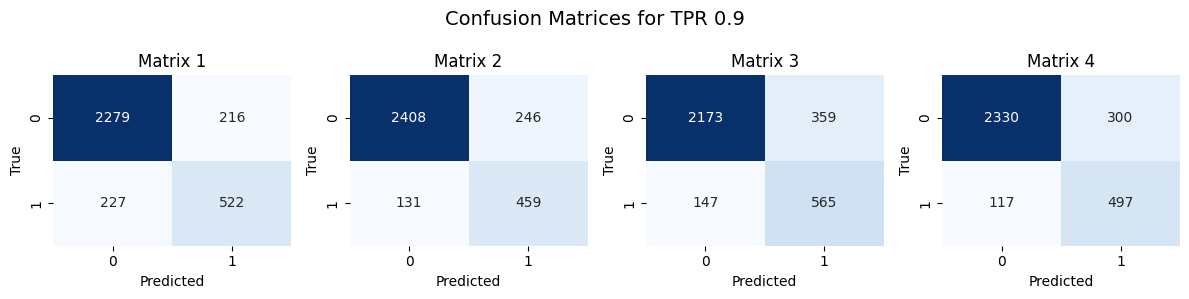

In [10]:

cms_list = matrices_dict[0.99]
quick_visualize_matrices(matrices_dict[0.8], 0.9)



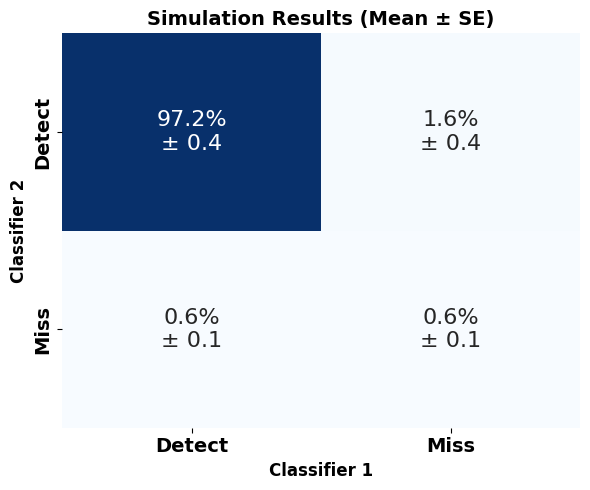

(array([[97.20252774,  1.60295931],
        [ 0.61652281,  0.57799014]]),
 array([[0.42067142, 0.37395891],
        [0.06777079, 0.10557297]]))

In [11]:
plot_simulation_results(cms_list)


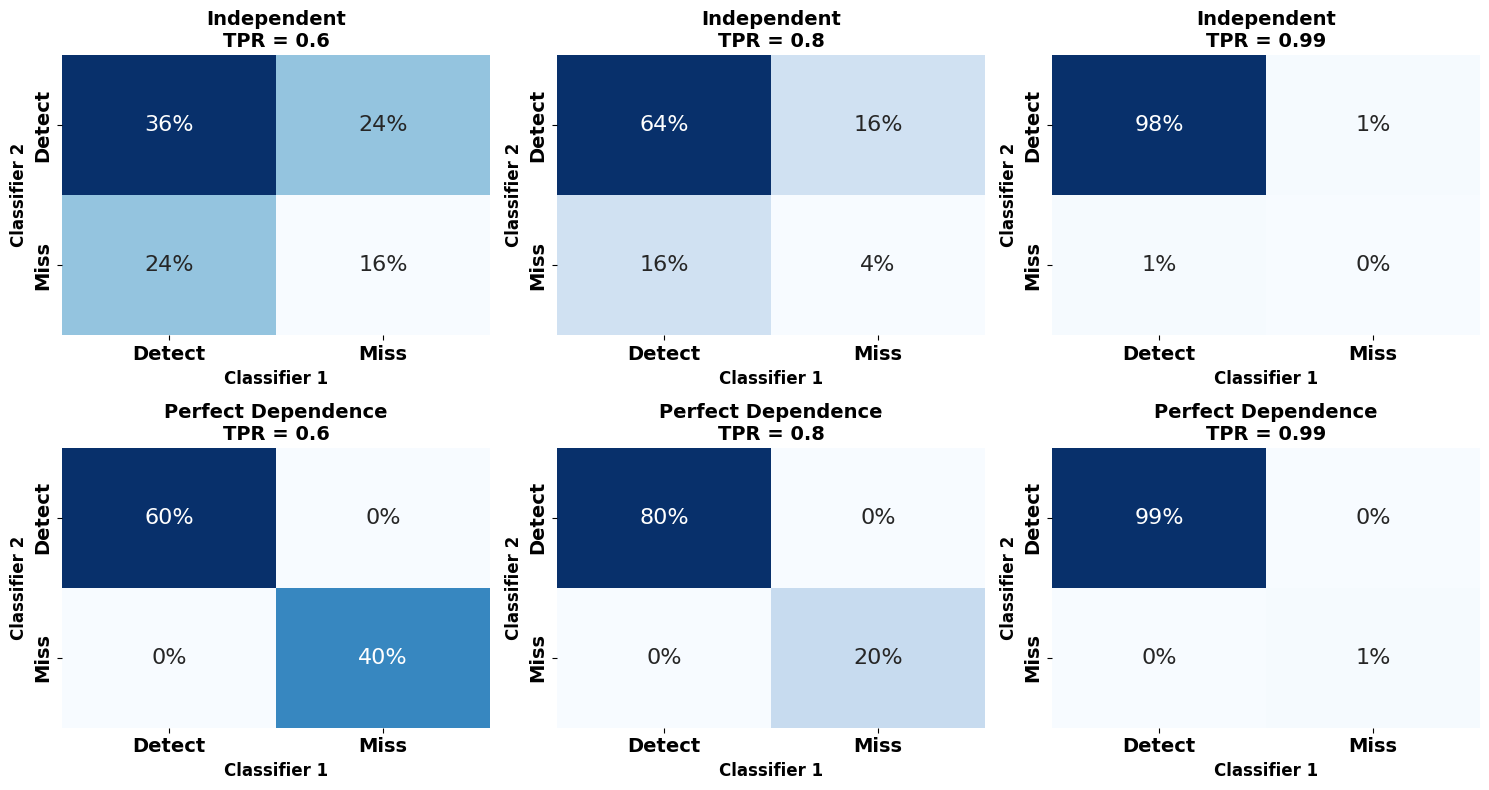

In [12]:
# For theoretical comparison:
plot_theoretical_comparison()

After Eval filter: 34 experiments
After subsample=False filter: 24 experiments
After iterations filter: 24 experiments
Final filtered dataset: 24 experiments

=== ANALYZING COLUMN: summary_Generated_ground_truth_lie_fraction ===

COMPREHENSIVE COMPARISON FOR COLUMN: summary_Generated_ground_truth_lie_fraction

Analyzing TPR 0.6 - Column: summary_Generated_ground_truth_lie_fraction
Total experiments for this TPR: 8
  1.0 iterations: Mean = 0.5250 ± 0.0275 (n=4 seeds)
    Seeds: [11.0, 22.0, 33.0, 44.0]
  2.0 iterations: Mean = 0.4150 ± 0.0465 (n=4 seeds)
    Seeds: [11.0, 22.0, 33.0, 44.0]
  Difference (2.0 - 1.0): -0.1100
  ----------------------------------------

Analyzing TPR 0.8 - Column: summary_Generated_ground_truth_lie_fraction
Total experiments for this TPR: 8
  1.0 iterations: Mean = 0.5100 ± 0.0370 (n=4 seeds)
    Seeds: [11.0, 22.0, 33.0, 44.0]
  2.0 iterations: Mean = 0.3475 ± 0.0165 (n=4 seeds)
    Seeds: [11.0, 22.0, 33.0, 44.0]
  Difference (2.0 - 1.0): -0.1625
  ------

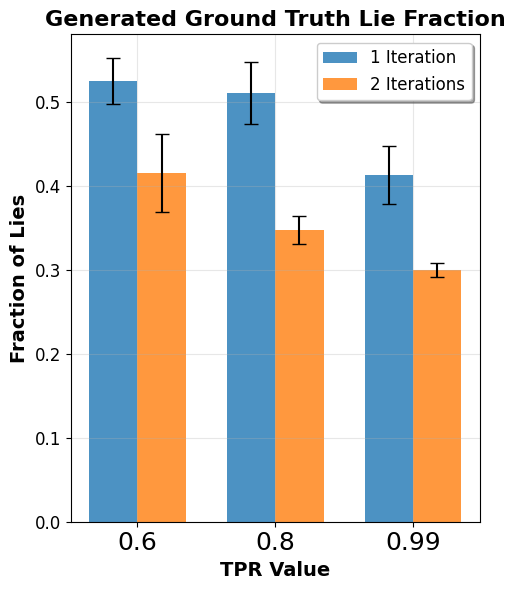

In [13]:
eval_df, results_dict, fig = run_multi_column_analysis(df_filled_last_iteration,
                                                      ['summary_Generated_ground_truth_lie_fraction'])